<a href="https://colab.research.google.com/github/Daniel20157/CSCI164/blob/main/CSCI164Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold  #necessary to train/split the data, GridSearchCV to find the optimal hyperparameters, and kfold to optimize the data
from sklearn.preprocessing import StandardScaler, OneHotEncoder # preprocessing to standarize the features
from sklearn.compose import ColumnTransformer # allows different transformers for the dataset
from sklearn.pipeline import Pipeline # Preprocessing to manage the workflow

from sklearn.linear_model import LogisticRegression # Model for Logistic Regresssion
from sklearn.neural_network import MLPClassifier # Model for Multi layer Perceptron
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_curve # Metrics

In [ ]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:

competition_path = kagglehub.competition_download("playground-series-s6e2") # dowloading the dataset from kaggle
print(os.listdir(competition_path))

100%|██████████| 10.2M/10.2M [00:02<00:00, 5.10MB/s]

Extracting files...


['train.csv', 'sample_submission.csv', 'test.csv']


In [ ]:
train_df = pd.read_csv(os.path.join(competition_path, 'train.csv')) # loading data set in panda data frame
test_df = pd.read_csv(os.path.join(competition_path, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(competition_path, 'sample_submission.csv'))
print(train_df.info())
print(train_df.head())
print(train_df.shape)
print(test_df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [ ]:
train_df['Heart Disease'].value_counts(normalize=True)

,proportion
Heart Disease,
Absence,0.55166
Presence,0.44834


In [ ]:
categorical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Thallium']
numerical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro']
# seperating the features into categorical columns and numerical columns for preprocessing

X = train_df.drop(columns=['Heart Disease', 'id'])
y = train_df['Heart Disease'].map({'Absence': 0, 'Presence': 1}) # Convert target to numerical
X_test = test_df.drop(columns=['id'])

In [ ]:
preprocessor = ColumnTransformer([ # Formatting the columns appropriately
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

In [ ]:
pipeline = Pipeline([ #Applying transformers and etimator for Logisitic Regression
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs'))
])

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, # splitting the data into training and validaiton sets
                                                  random_state=42, stratify=y)

In [ ]:
param_grid = { #defining hyperparameters
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'newton-cg']
}

grid = GridSearchCV(pipeline, param_grid, cv=StratifiedKFold(5), #Initialize GridSearch
                    scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train) # Training and looking for the best verion

print("\nBest parameters:", grid.best_params_)
print("Best cross-validation ROC-AUC:", grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'newton-cg'}
Best cross-validation ROC-AUC: 0.9530050458574297


In [ ]:
best_model = grid.best_estimator_ #Best performing parameters with logistic regression model
y_pred = best_model.predict(X_val) # class predictions
y_proba = best_model.predict_proba(X_val)[:, 1] # Needed for ROC-AUC to predict positive classes

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, pos_label=1)
rec = recall_score(y_val, y_pred, pos_label=1)
f1 = f1_score(y_val, y_pred, pos_label=1)

roc_auc = roc_auc_score(y_val, y_proba)

print("\n=== Validation Performance ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== Validation Performance ===
Accuracy:  0.8881
Precision: 0.8841
Recall:    0.8636
F1-score:  0.8737
ROC-AUC:   0.9543


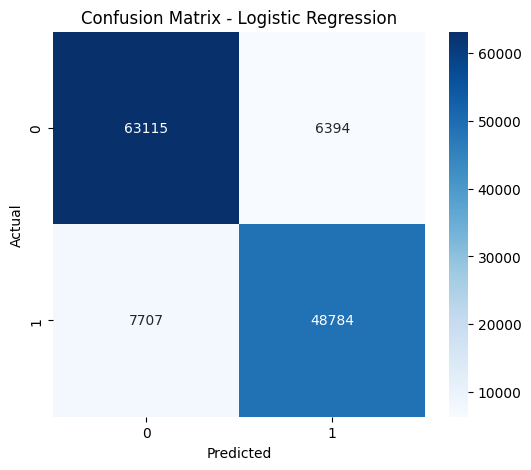

In [ ]:
m = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(m, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

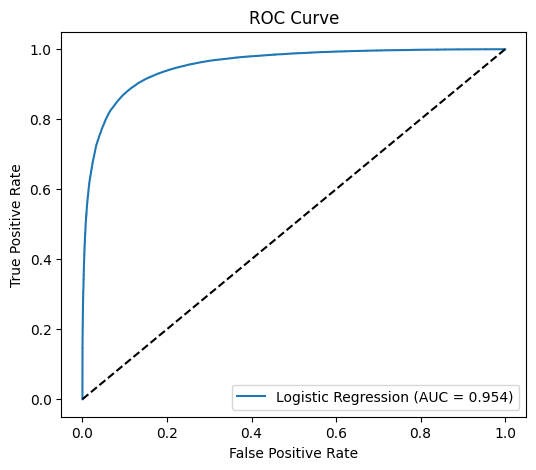

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

In [ ]:
mlp_param_grid = { #defining hyperparameters for MLP grid
    'classifier__hidden_layer_sizes': [(100,)],
    'classifier__activation': ['relu'],
    'classifier__alpha': [0.001, 0.01],
    'classifier__learning_rate_init': [0.001]
}

mlp_grid_cv = GridSearchCV(mlp_pipeline, mlp_param_grid, cv=StratifiedKFold(2),  #Initialize GridSearch
                                 scoring='roc_auc', n_jobs=-1, verbose=1)
mlp_grid_cv.fit(X_train, y_train) #tuning and looking for the best model

print(f"\nBest parameters : {mlp_grid_cv.best_params_}")
print(f"Best cross-validation ROC-AUC : {mlp_grid_cv.best_score_:.4f}")

Fitting 2 folds for each of 2 candidates, totalling 4 fits

Best parameters : {'classifier__activation': 'relu', 'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (100,), 'classifier__learning_rate_init': 0.001}
Best cross-validation ROC-AUC : 0.9542


In [ ]:
mlp_best = mlp_grid_cv.best_estimator_ #Best performing parameters with MLP model
mlp_pred = mlp_grid_cv.predict(X_val)
mlp_proba = mlp_grid_cv.predict_proba(X_val)[:, 1]

mlp_metrics = {
    'Accuracy': accuracy_score(y_val, mlp_pred),
    'Precision': precision_score(y_val, mlp_pred),
    'Recall': recall_score(y_val, mlp_pred),
    'F1-score': f1_score(y_val, mlp_pred),
    'ROC-AUC': roc_auc_score(y_val, mlp_proba)
}

print("\n=== MLP Validation Performance ===")
for metric, value in mlp_metrics.items():
    print(f"{metric}: {value:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== MLP Validation Performance ===
Accuracy: 0.8887
Precision: 0.8780
Recall: 0.8731
F1-score: 0.8756
ROC-AUC: 0.9553


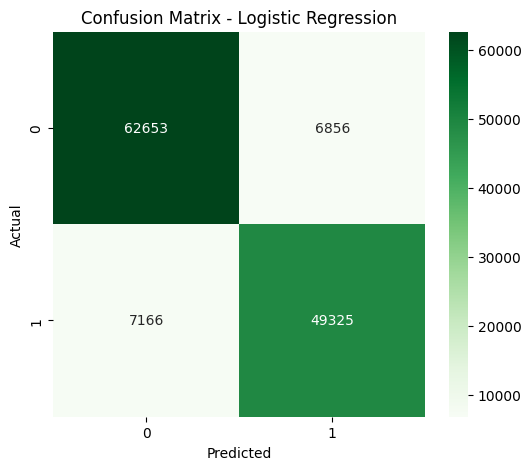

In [ ]:
m = confusion_matrix(y_val, mlp_pred)
plt.figure(figsize=(6,5))
sns.heatmap(m, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

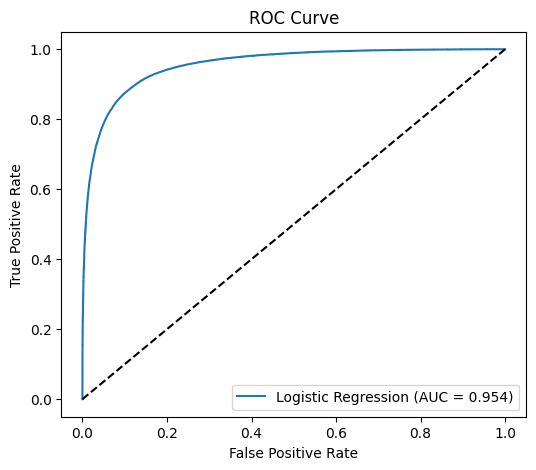

In [ ]:
fpr, tpr, _ = roc_curve(y_val, mlp_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
lr_metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1-score': f1_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_proba)
}

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': list(lr_metrics.keys()),
    'Logistic Regression': list(lr_metrics.values()),
    'MLP': list(mlp_metrics.values())
})
print(comparison_df.to_string(index=False))

   Metric  Logistic Regression      MLP
 Accuracy             0.888087 0.888714
Precision             0.884120 0.877966
   Recall             0.863571 0.873148
 F1-score             0.873725 0.875550
  ROC-AUC             0.954280 0.955261


In [ ]:
def compute_oof_auc(model_pipeline, X, y, n_splits=5, random_state=42): #implementation to comput OOF AUC
    """
    Compute Out-Of-Fold AUC for a given model pipeline.

    Parameters:
    - model_pipeline: a sklearn Pipeline (or any estimator with .fit and .predict_proba)
    - X: features (DataFrame or array)
    - y: target (Series or array)
    - n_splits: number of folds
    - random_state: for reproducibility

    Returns:
    - oof_auc: float, the ROC‑AUC on OOF predictions
    - oof_probas: array of predicted probabilities for the whole dataset (same order as y)
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_probas = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]

        from sklearn.base import clone   # Cloning the pipeline to avoid overwriting parameters

        model_fold = clone(model_pipeline)
        model_fold.fit(X_train_fold, y_train_fold)

        proba_val = model_fold.predict_proba(X_val_fold)[:, 1]
        oof_probas[val_idx] = proba_val

        print(f"Fold {fold+1} done.")

    oof_auc = roc_auc_score(y, oof_probas)
    return oof_auc, oof_probas

In [ ]:
best_model = grid.best_params_
final_lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=best_model['classifier__C'],
        solver=best_model['classifier__solver'],
        random_state=42, max_iter=1000
    ))
])

oof_auc_lr, oof_probas_lr = compute_oof_auc(final_lr_pipeline, X, y, n_splits=5)
print(f"Logistic Regression OOF AUC = {oof_auc_lr:.5f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 1 done.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 2 done.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 3 done.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 4 done.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 5 done.
Logistic Regression OOF AUC = 0.95328


In [ ]:
mlp_best = mlp_grid_cv.best_params_
final_mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=mlp_best['classifier__hidden_layer_sizes'],
        activation=mlp_best['classifier__activation'],
        alpha=mlp_best['classifier__alpha'],
        learning_rate_init=mlp_best['classifier__learning_rate_init'],
        random_state=42, max_iter=1000, early_stopping=True
    ))
])

oof_auc_mlp, oof_probas_mlp = compute_oof_auc(final_mlp_pipeline, X, y, n_splits=5)
print(f"MLP OOF AUC = {oof_auc_mlp:.5f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 1 done.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 2 done.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 3 done.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 4 done.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 5 done.
MLP OOF AUC = 0.95475
